In [5]:
#Name: Mohebul Hasan Emon
#ID: EMO22509146
#Project Name: Diabetes Prediction Data Analysis
#Purpose: Data Science Coursework 2
#Start Date: 20.04.2024
#Last Updated: 2.05.2024

In [6]:
#Importing nessasary library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [7]:
# Load the dataset
diabetes_data = pd.read_csv('Diabetes.csv')

# Print the first few rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,3,78,50,32,88,31.0,0.248,26,1


In [8]:
# Check for duplicates and remove them if found
if diabetes_data.duplicated().any():
    print("Found duplicate rows. Removing them...")
    diabetes_data.drop_duplicates(inplace=True)

In [9]:
#Print dataset info
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               531 non-null    int64  
 1   Glucose                   531 non-null    int64  
 2   BloodPressure             531 non-null    int64  
 3   SkinThickness             531 non-null    int64  
 4   Insulin                   531 non-null    int64  
 5   BMI                       531 non-null    float64
 6   DiabetesPedigreeFunction  531 non-null    float64
 7   Age                       531 non-null    int64  
 8   Outcome                   531 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 37.5 KB


In [10]:
#dataset overview with all the mean and std
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000,531.000000
mean,3.514124,121.071563,71.538606,29.184557,115.048964,32.888136,0.502974,31.617702,0.333333
std,3.314532,31.013670,12.298332,10.533676,123.115690,6.887428,0.344871,10.771503,0.471849
min,0.000000,56.000000,24.000000,7.000000,0.000000,18.200000,0.085000,21.000000,0.000000
25%,1.000000,98.500000,64.000000,22.000000,0.000000,27.850000,0.258500,23.000000,0.000000
50%,2.000000,115.000000,72.000000,29.000000,92.000000,32.800000,0.415000,28.000000,0.000000
75%,5.000000,141.500000,80.000000,36.000000,165.500000,36.900000,0.659000,38.000000,1.000000
max,17.000000,199.000000,110.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
# number of row's and col in data set
row,col=diabetes_data.shape
print("Number of Row's in Data :",row)
print("Number of Column's in Data :",col)
print("Shape of Dataset",diabetes_data.shape)

Number of Row's in Data : 531
Number of Column's in Data : 9
Shape of Dataset (531, 9)


In [12]:
# Select predictors (glucose, blood pressure, and BMI) and outcome
predictors = diabetes_data[['Glucose', 'BloodPressure', 'BMI']]
outcome = diabetes_data['Outcome']

print("The shape of the NumPy array pridictors containing the predictors is:", predictors.shape)
print (predictors)
print("")
print("")
print("The shape of the NumPy array outcomes containing the label is:",outcome.shape)
print (outcome)

The shape of the NumPy array pridictors containing the predictors is: (531, 3)
     Glucose  BloodPressure   BMI
0        148             72  33.6
1         85             66  26.6
2         89             66  28.1
3        137             40  43.1
4         78             50  31.0
..       ...            ...   ...
526      170             74  44.0
527      101             76  32.9
528      122             70  36.8
529      121             72  26.2
530       93             70  30.4

[531 rows x 3 columns]


The shape of the NumPy array outcomes containing the label is: (531,)
0      1
1      0
2      0
3      1
4      1
      ..
526    1
527    0
528    0
529    0
530    0
Name: Outcome, Length: 531, dtype: int64


<ipython-input-13-22c6e1544cb8>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=diabetes_data, x='Outcome', palette=colors)


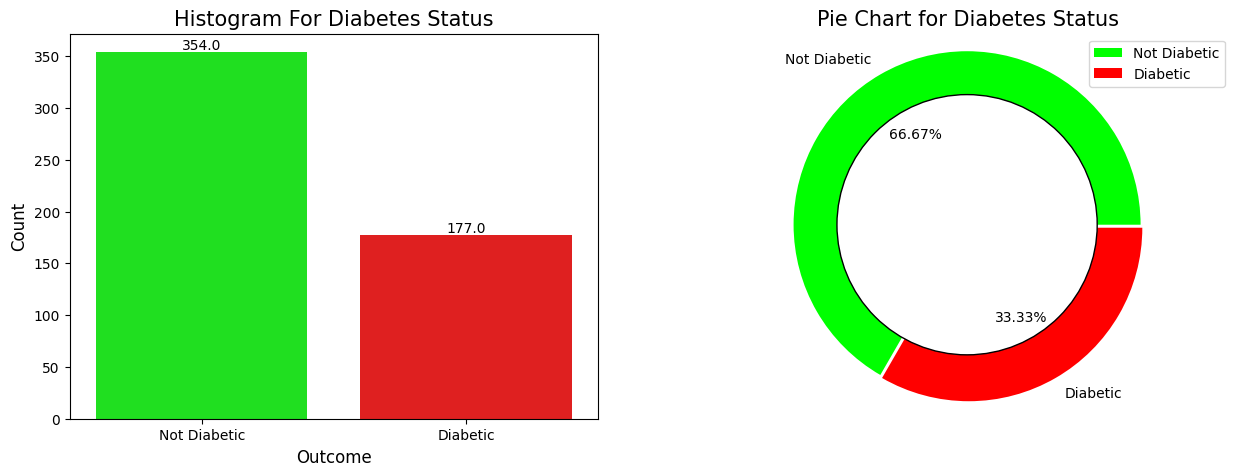

In [13]:
# Visualize the distribution of outcomes
labels = ['Not Diabetic', 'Diabetic']
colors = ['#00FF00', '#FF0000']
plt.figure(figsize=(15,5))

# Subplot for the count plot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=diabetes_data, x='Outcome', palette=colors)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('Histogram For Diabetes Status', size=15)
plt.xlabel('Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0, 1], labels=labels)  # Labeling x-axis ticks

# Subplot for the pie chart
plt.subplot(1, 2, 2)
y = diabetes_data['Outcome'].value_counts()
explode = [0, 0.02]
plt.pie(y, labels=labels, colors=colors, explode=explode, autopct='%.2f%%')
plt.axis('equal')
plt.legend(labels)
circle = plt.Circle(xy=(0, 0), radius=0.75, facecolor='white', edgecolor='black')
plt.gca().add_artist(circle)
plt.title('Pie Chart for Diabetes Status', size=15)

plt.show()

Highest Glucose: 199
Lowest Glucose: 56
Highest BloodPressure: 110
Lowest BloodPressure: 24
Highest BMI: 67.1
Lowest BMI: 18.2


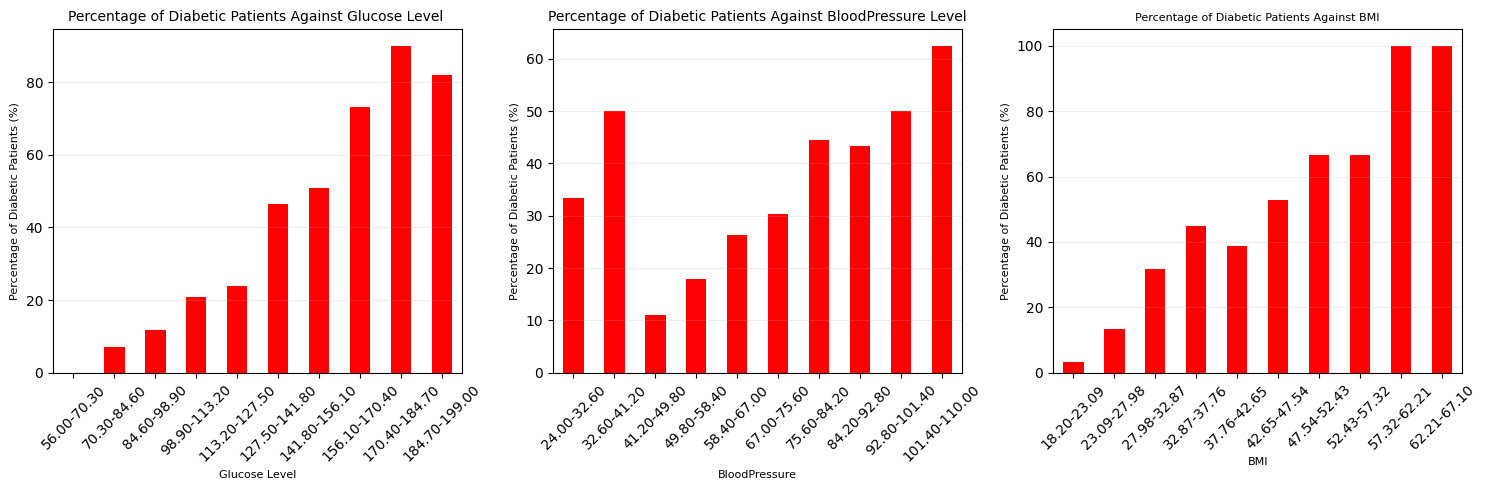

In [14]:
#Visualization of GLUCOSE, BLOODPRESSURE AND BMI DATA AGAINST OUTCOME

# Find the highest and lowest values for Glucose, BloodPressure, and BMI
highest_glucose = diabetes_data['Glucose'].max()
lowest_glucose = diabetes_data['Glucose'].min()
highest_bp = diabetes_data['BloodPressure'].max()
lowest_bp = diabetes_data['BloodPressure'].min()
highest_bmi = diabetes_data['BMI'].max()
lowest_bmi = diabetes_data['BMI'].min()

print("Highest Glucose:", highest_glucose)
print("Lowest Glucose:", lowest_glucose)
print("Highest BloodPressure:", highest_bp)
print("Lowest BloodPressure:", lowest_bp)
print("Highest BMI:", highest_bmi)
print("Lowest BMI:", lowest_bmi)

#number of groups
num_groups = 10

# Calculate the Group size for Glucose, BloodPressure, and BMI
glucose_groups_size = (highest_glucose - lowest_glucose) / num_groups
bp_groups_size = (highest_bp - lowest_bp) / num_groups
bmi_groups_size = (highest_bmi - lowest_bmi) / num_groups

# Create groups based on the groups size for Glucose, BloodPressure, and BMI
glucose_groups = [lowest_glucose + i * glucose_groups_size for i in range(num_groups)]
glucose_groups.append(highest_glucose)  # Include the highest value as the last groups endpoint

bp_groups = [lowest_bp + i * bp_groups_size for i in range(num_groups)]
bp_groups.append(highest_bp)  # Include the highest value as the last group endpoint

bmi_groups = [lowest_bmi + i * bmi_groups_size for i in range(num_groups)]
bmi_groups.append(highest_bmi)  # Include the highest value as the last group endpoint

# Create new columns 'GlucoseGroup', 'BloodPressureGroup', and 'BMIGroup' which indicate the group for each Glucose, BloodPressure, and BMI value
diabetes_data['GlucoseGroup'] = pd.cut(diabetes_data['Glucose'], bins=glucose_groups, labels=[f'{glucose_groups[i]:.2f}-{glucose_groups[i+1]:.2f}' for i in range(num_groups)], include_lowest=True)
diabetes_data['BloodPressureGroup'] = pd.cut(diabetes_data['BloodPressure'], bins=bp_groups, labels=[f'{bp_groups[i]:.2f}-{bp_groups[i+1]:.2f}' for i in range(num_groups)], include_lowest=True)
diabetes_data['BMIGroup'] = pd.cut(diabetes_data['BMI'], bins=bmi_groups, labels=[f'{bmi_groups[i]:.2f}-{bmi_groups[i+1]:.2f}' for i in range(num_groups)], include_lowest=True)

# Create functions to calculate the parcentage of diabetic patients for each group
def calculate_parcentage(df, column):
    group_counts = df[column].value_counts()
    diabetic_counts = df.groupby(column)['Outcome'].sum()
    return (diabetic_counts / group_counts) * 100

# Calculate the percentage of diabetic patients for each group of Glucose, BloodPressure, and BMI
percentage_glucose_diabetic = calculate_parcentage(diabetes_data, 'GlucoseGroup')
percentage_bp_diabetic = calculate_parcentage(diabetes_data, 'BloodPressureGroup')
percentage_bmi_diabetic = calculate_parcentage(diabetes_data, 'BMIGroup')

# Visualization the percentage of diabetic patients against Glucose Level
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
percentage_glucose_diabetic.plot(kind='bar', color='#FF0000')
plt.title('Percentage of Diabetic Patients Against Glucose Level ', size=10)
plt.xlabel('Glucose Level', fontsize=8)
plt.ylabel('Percentage of Diabetic Patients (%)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

# Visualization the percentage of diabetic patients against Blood Pressure Level
plt.subplot(1, 3, 2)
percentage_bp_diabetic.plot(kind='bar', color='#FF0000')
plt.title('Percentage of Diabetic Patients Against BloodPressure Level', size=10)
plt.xlabel('BloodPressure', fontsize=8)
plt.ylabel('Percentage of Diabetic Patients (%)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

# Visualization the percentage of diabetic patients against BMI
plt.subplot(1, 3, 3)
percentage_bmi_diabetic.plot(kind='bar', color='#FF0000')
plt.title('Percentage of Diabetic Patients Against BMI', size=8)
plt.xlabel('BMI', fontsize=8)
plt.ylabel('Percentage of Diabetic Patients (%)', fontsize=8)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()



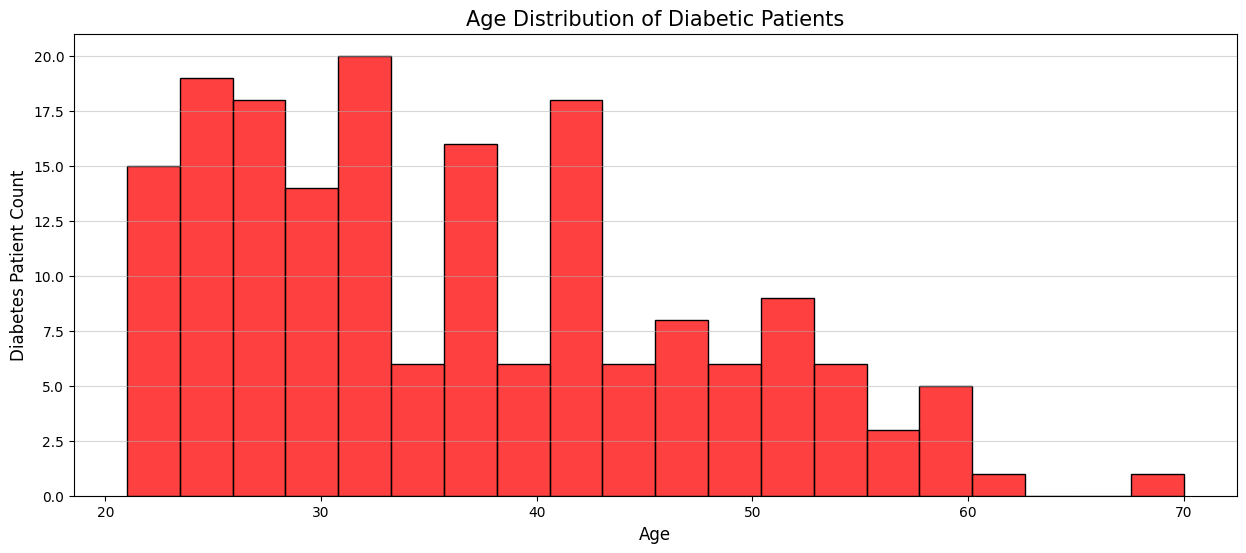

In [15]:
#Visualization Age DATA AGAINST OUTCOME

# Filter the dataset for diabetic patients with outcome value 1
diabetic_data_1 = diabetes_data[diabetes_data['Outcome'] == 1]

# Graph for age distribution for diabetic patients
plt.figure(figsize=(15, 6))
sns.histplot(diabetic_data_1['Age'], bins=20, color='red', kde=False)
plt.title('Age Distribution of Diabetic Patients', size=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Diabetes Patient Count', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()


Highest DiabetesPedigreeFunction: 2.42
Lowest DiabetesPedigreeFunction: 0.085


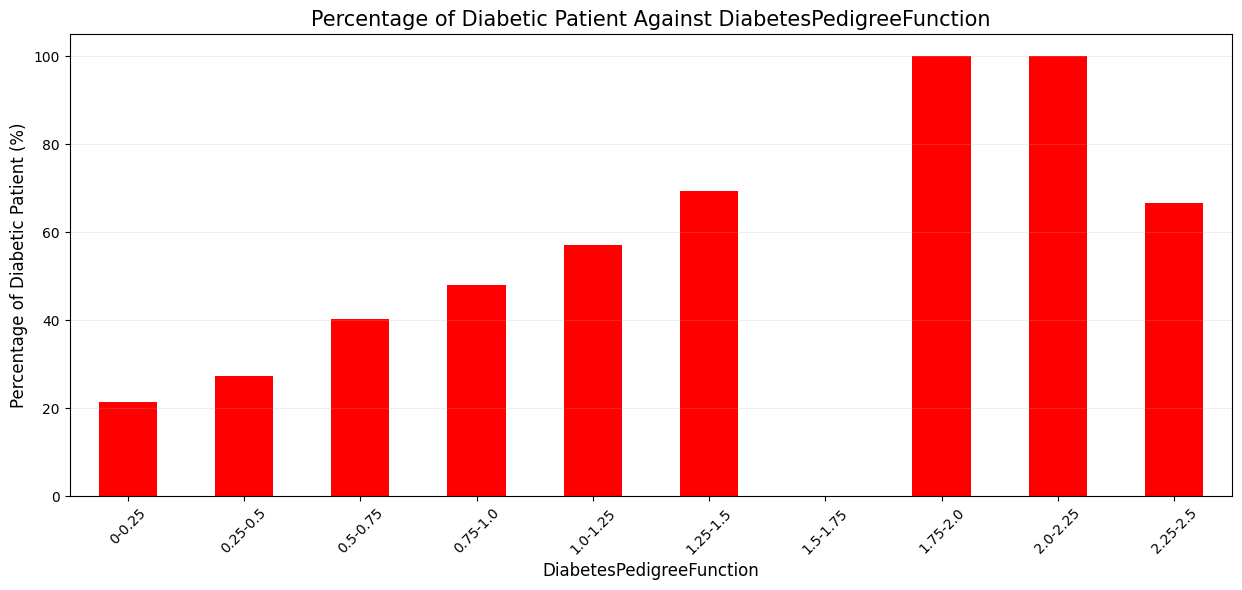

In [16]:
#Graph to Show the Parcentage of Diabetic People in each Group of Diabetes Pedigree Function

# Find the highest value of DiabetesPedigreeFunction
highest_diabetes_pedigree = diabetes_data['DiabetesPedigreeFunction'].max()
# Find the lowest value of DiabetesPedigreeFunction
lowest_diabetes_pedigree = diabetes_data['DiabetesPedigreeFunction'].min()
print("Highest DiabetesPedigreeFunction:", highest_diabetes_pedigree)
print("Lowest DiabetesPedigreeFunction:", lowest_diabetes_pedigree)

# Define the groups for DiabetesPedigreeFunction
groups_ = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]

# Create a new column 'PedigreeGroup' which indicates the group for each DiabetesPedigreeFunction value
diabetes_data['PedigreeGroup'] = pd.cut(diabetes_data['DiabetesPedigreeFunction'], bins=groups_, labels=[f'{i}-{j}' for i, j in zip(groups_[:-1], groups_[1:])], include_lowest=True)

# Calculate the total count of patient in each group of DiabetesPedigreeFunction
group_counts = diabetes_data['PedigreeGroup'].value_counts()

# Calculate the count of diabetic patient in each group of DiabetesPedigreeFunction
diabetic_counts = diabetes_data.groupby('PedigreeGroup')['Outcome'].sum()

# Calculate the percentage of diabetic patient for each group of DiabetesPedigreeFunction
percentage_diabetic = (diabetic_counts / group_counts) * 100

# Visualize the percentage of diabetic patient against DiabetesPedigreeFunction groups
plt.figure(figsize=(15, 6))
percentage_diabetic.plot(kind='bar', color='#FF0000')
plt.title('Percentage of Diabetic Patient Against DiabetesPedigreeFunction', size=15)
plt.xlabel('DiabetesPedigreeFunction', fontsize=12)
plt.ylabel('Percentage of Diabetic Patient (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)
plt.show()


In [17]:
# Split the dataset into training and test datasets
x_train, x_test, y_train, y_test = train_test_split(predictors, outcome, test_size=0.05, random_state=42)

In [18]:


# Define the range of k values
k_values = range(1, 75, 6)

# Create an empty dictionary to store accuracy for each k value
accuracy = {}

# Iterate over each value of k
for k in k_values:
    # Create kNN classifier with k neighbors
    knn = KNeighborsClassifier(n_neighbors=k)
    # Fit the model to the training data
    knn.fit(x_train, y_train)
    # Predict the Test data Outcome
    y_test_pred = knn.predict(x_test)
    # Calculate accuracy
    acc = accuracy_score(y_test, y_test_pred)
    # Store accuracy for current k
    accuracy[k] = acc

# Find the value of k with the highest accuracy
best_k = max(accuracy, key=accuracy.get)
best_accuracy = accuracy[best_k]




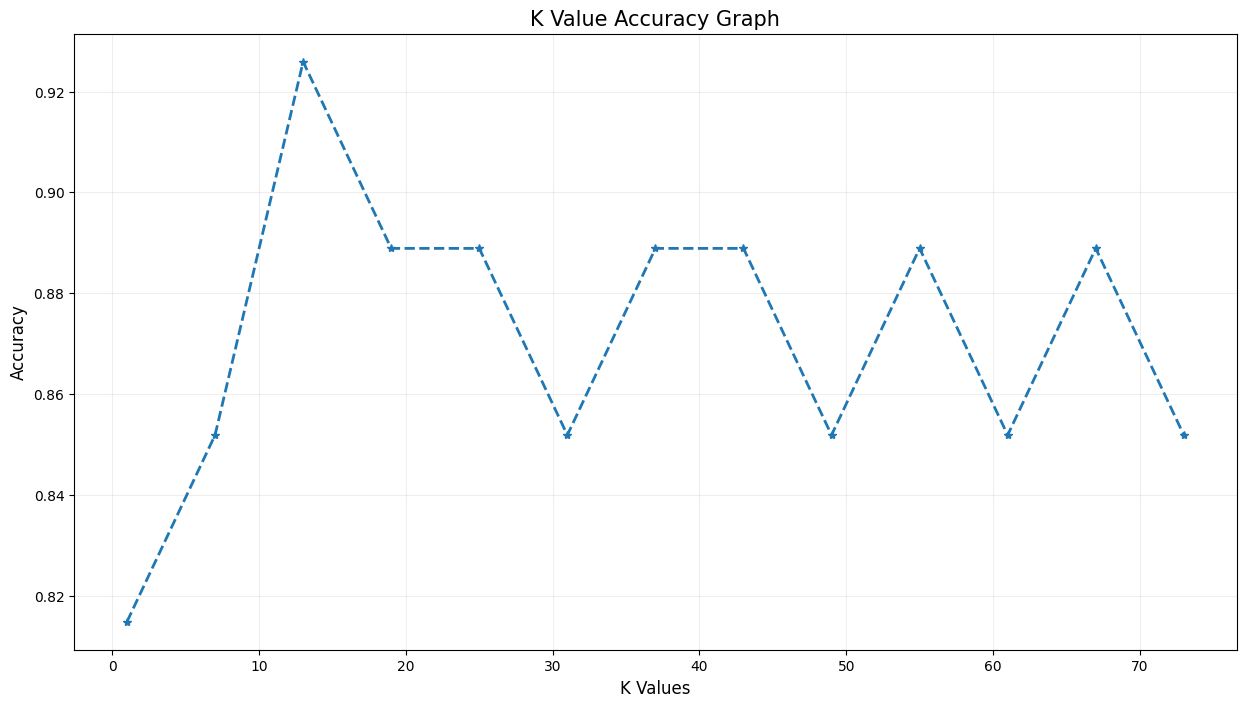

Best K Value is: 13 with 92.59% Accuracy


In [19]:
# Plot validation accuracy as a function of k
plt.figure(figsize=(15, 8))
plt.plot(k_values, list(accuracy.values()), '--*', linewidth=2)
plt.xlabel("K Values", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(alpha=0.2)
plt.title("K Value Accuracy Graph", size=15)
plt.show()

print("Best K Value is:", best_k, "with", f"{(best_accuracy * 100):.2f}%", "Accuracy")


In [20]:
#input raw data for prediction for Hypothsis 1
glucose = float(input("Enter Glucose level: "))
blood_pressure = float(input("Enter Blood Pressure: "))
bmi = float(input("Enter BMI: "))

# Create a DataFrame with the user input
user_data = pd.DataFrame({'Glucose': [glucose], 'BloodPressure': [blood_pressure], 'BMI': [bmi]})

# Predict the outcome for user input
predicted_outcome = knn.predict(user_data)

# Interpret the predicted outcome
if predicted_outcome[0] == 1:
    print("The person has Diabetes.")
else:
    print("The person does not have Diabetes.")

Enter Glucose level: 70
Enter Blood Pressure: 40
Enter BMI: 22
The person does not have Diabetes.


In [23]:

# Hypothesis 2 predictor and outcome
h2_predictor = diabetes_data[['Age']]
h2_outcome = diabetes_data['Outcome']

# Split the dataset into training and test datasets
x_train, x_test, y_train, y_test = train_test_split(h2_predictor, h2_outcome, test_size=0.05, random_state=42)

# Define the KNeighborsClassifier with k=13
knn = KNeighborsClassifier(n_neighbors=13)

# Train the model on the training dataset
knn.fit(x_train, y_train)

# Predict the labels of test dataset
y_pred = knn.predict(x_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Input raw data for prediction
age = float(input("Enter Age: "))

# Create a DataFrame with the user input
user_data = pd.DataFrame({'Age': [age]})

# Predict the outcome for user input
predicted_outcome = knn.predict(user_data)

# Interpret the predicted outcome
if predicted_outcome[0] == 1:
    print("The person is at high risk of Diabetes.")
else:
    print("The person is at low risk of Diabetes.")

Accuracy: 0.7037037037037037
Enter Age: 22
The person is at high risk of Diabetes.


In [22]:
# Predictors for Hypothesis 3 DiabetesPedigreeFunction and outcome
h3_predictor = diabetes_data[['DiabetesPedigreeFunction']]
h3_outcome = diabetes_data['Outcome']

# Split the dataset into training and test datasets
x_train, x_test, y_train, y_test = train_test_split(h3_predictor, h3_outcome, test_size=0.05, random_state=42)

# Define the KNeighborsClassifier with k=19
knn = KNeighborsClassifier(n_neighbors=19)

# Train the model on the training dataset
knn.fit(x_train, y_train)

# Predict the labels of test dataset
y_pred = knn.predict(x_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Input raw data for prediction
diabetes_pedigree_function = float(input("Enter Diabetes Pedigree Function: "))

# Create a DataFrame with the user input
user_data = pd.DataFrame({'DiabetesPedigreeFunction': [diabetes_pedigree_function]})

# Predict the outcome for user input
predicted_outcome = knn.predict(user_data)

# Interpret the predicted outcome
if predicted_outcome[0] == 1:
    print("The person has Diabetes.")
else:
    print("The person does not have Diabetes.")

Accuracy: 0.5925925925925926
Enter Diabetes Pedigree Function: 2
The person has Diabetes.
